In [15]:
import pandas as pd
import numpy as np
import collections

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Bidirectional,
    BatchNormalization, GlobalAveragePooling1D
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l2
import tensorflow as tf



### **Cargar Datos**

In [16]:
ruta_csv = r"C:\Users\USER\OneDrive - universidadean.edu.co\2. Semestre\Seminario de investigación\Modulo 2\Modelo ML\data\processed\df_preprocesado_LSTM_binario.csv"

df = pd.read_csv(ruta_csv, parse_dates=['FECHA_CIERRE'])

### **Preprocesamiento**

In [17]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

timesteps = 10
target_col = 'ETIQUETA_MORA'

feature_cols = df.select_dtypes(include=[np.number]).columns.difference([
    target_col, 'NUMERO DE LA COLOCACION', 'MORA_SIGUIENTE'
])

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df_scaled[feature_cols])
df_scaled = df_scaled.sort_values(['NUMERO DE LA COLOCACION', 'FECHA_CIERRE'])

In [18]:
feature_cols

Index(['ACIERTA', 'ANTIGUEDAD_CREDITO_MESES', 'ANTIGÜEDAD LABORAL',
       'CALIFICACION CARTERA', 'CAPITAL PEND POR FACT',
       'DIA VENCIMIENTO CUOTA', 'DIAS DE MORA', 'DIAS_CUOTA_PENDIENTE',
       'DIAS_DESDE_ULTIMO_PAGO', 'DIAS_HASTA_PROX_PAGO',
       'ESTADO CIVIL_DIVORCIADO', 'ESTADO CIVIL_RELIGIOSO',
       'ESTADO CIVIL_SEPARADO', 'ESTADO CIVIL_SIN INFORMACION',
       'ESTADO CIVIL_SOLTERO', 'ESTADO CIVIL_UNION LIBRE',
       'ESTADO CIVIL_VIUDO', 'INGRESOS', 'MARCA', 'MORA_ACTUAL',
       'NIVEL DE ESTUDIOS', 'NRO CUOTAS PAGADAS', 'NRO CUOTAS RESTANTE',
       'NRO CUOTAS VENCIDAS', 'NRO DE UTILIZACINES D', 'NRO PLAN PAGOS VIGENT',
       'NUMERO DE IDENTIFICACION DEUDOR', 'NUMERO DE PAGOS PACTA',
       'NUMERO DE PERSONAS A CARGO', 'NUMERO DEL PRODUCTO',
       'OCUPACIÓN_COMERCIANTE', 'OCUPACIÓN_OTRO',
       'OCUPACIÓN_PROFESIONAL INDEPENDIENTE', 'OCUPACIÓN_RENTISTA DE CAPITAL',
       'OCUPACIÓN_SIN INFORMACION', 'PLAZO EN DIAS', 'PRODUCTO',
       'SALDO DEL PRESTAM

In [19]:
pd.set_option('display.max_rows', 15)
pd.set_option('display.max_columns', None)

df_scaled

,NUMERO DE LA COLOCACION,NUMERO DE IDENTIFICACION DEUDOR,NUMERO DEL PRODUCTO,PLAZO EN DIAS,NUMERO DE PAGOS PACTA,VALOR ORIGINAL DEL PR,CAPITAL PEND POR FACT,SALDO DEL PRESTAMO,NRO PLAN PAGOS VIGENT,NRO DE UTILIZACINES D,DIAS DE MORA,CALIFICACION CARTERA,VLR ULTIMO PAGO,VLR TASA,VLR CUOTA MES,VLR MINIMO DE PAGO,DIA VENCIMIENTO CUOTA,NRO CUOTAS VENCIDAS,NRO CUOTAS PAGADAS,NRO CUOTAS RESTANTE,NIVEL DE ESTUDIOS,MARCA,ACIERTA,ANTIGÜEDAD LABORAL,NUMERO DE PERSONAS A CARGO,INGRESOS,PRODUCTO,FECHA_CIERRE,MORA_ACTUAL,MORA_SIGUIENTE,ETIQUETA_MORA,ANTIGUEDAD_CREDITO_MESES,DIAS_HASTA_PROX_PAGO,DIAS_DESDE_ULTIMO_PAGO,DIAS_CUOTA_PENDIENTE,TIPO DE SOLICITANTE_INDEPENDIENTE,TIPO DE SOLICITANTE_SIN INFORMACION,TIPO DE SOLICITANTE_TAXISTA,TIPO DE SOLICITANTE_TRANSPORTADOR,TIPO DE ID_CEDULA,TIPO DE ID_CEDULA DE EXTRANJERIA,TIPO DE ID_NIT,TIPO DE ID_OTROS,TIPO DE ID_SIN INFORMACION,OCUPACIÓN_COMERCIANTE,OCUPACIÓN_OTRO,OCUPACIÓN_PROFESIONAL INDEPENDIENTE,OCUPACIÓN_RENTISTA DE CAPITAL,OCUPACIÓN_SIN INFORMACION,TIPO DE VIVIENDA_FAMILIAR,TIPO DE VIVIENDA_PROPIA,TIPO DE VIVIENDA_SIN INFORMACION,ESTADO CIVIL_DIVORCIADO,ESTADO CIVIL_RELIGIOSO,ESTADO CIVIL_SEPARADO,ESTADO CIVIL_SIN INFORMACION,ESTADO CIVIL_SOLTERO,ESTADO CIVIL_UNION LIBRE,ESTADO CIVIL_VIUDO,TIPO DE VEHICULO_OTRO,TIPO DE VEHICULO_SIN INFORMACION,TIPO DE VEHICULO_USADO,TIPO DE SERVICIO_PARTICULAR,TIPO DE SERVICIO_PUBLICO,TIPO DE SERVICIO_SIN INFORMACION
0,90,-0.430401,2.074386,0.595352,0.607556,0.533252,-0.882649,-0.398817,-0.163124,1.78463,2.02225,2.306308,3.885328,-2.166454,-0.508992,1.389533,-0.985918,1.774218,0.413521,0.371115,-1.959162,-0.173557,-1.902437,-0.006813,0.0,0.441944,-1.941874,2024-01-31,1.650329,1.0,1,2.240300,-2.735237,3.55329,3.115581,1.252698,-0.436675,-0.038521,-0.124389,0.431331,-0.121805,-0.100135,-0.031836,-0.388191,-0.402556,-0.150853,-0.190773,-0.100887,0.519463,1.096229,-0.706753,-0.434749,-0.032981,-0.053367,-0.068841,-0.434749,-0.515437,1.050620,-0.074078,-0.438117,-0.076074,-0.417432,0.637406,-0.273384,-0.248883
1,90,-0.430401,2.074386,0.595352,0.607556,0.533252,-0.882649,-0.398817,-0.163124,1.78463,2.02225,2.306308,3.885328,-2.166454,-0.508992,1.391070,-0.985918,1.774218,0.413521,0.371115,-1.959162,-0.173557,-1.902437,-0.006813,0.0,0.441944,-1.941874,2024-02-28,1.650329,1.0,1,2.240300,-2.735237,3.55329,3.115581,1.252698,-0.436675,-0.038521,-0.124389,0.431331,-0.121805,-0.100135,-0.031836,-0.388191,-0.402556,-0.150853,-0.190773,-0.100887,0.519463,1.096229,-0.706753,-0.434749,-0.032981,-0.053367,-0.068841,-0.434749,-0.515437,1.050620,-0.074078,-0.438117,-0.076074,-0.417432,0.637406,-0.273384,-0.248883
2,90,-0.430401,2.074386,0.595352,0.607556,0.533252,-0.882649,-0.398817,-0.163124,1.78463,2.02225,2.306308,3.885328,-2.166454,-0.508992,1.392730,-0.985918,1.774218,0.413521,0.371115,-1.959162,-0.173557,-1.902437,-0.006813,0.0,0.441944,-1.941874,2024-03-30,1.650329,1.0,1,2.240300,-2.735237,3.55329,3.115581,1.252698,-0.436675,-0.038521,-0.124389,0.431331,-0.121805,-0.100135,-0.031836,-0.388191,-0.402556,-0.150853,-0.190773,-0.100887,0.519463,1.096229,-0.706753,-0.434749,-0.032981,-0.053367,-0.068841,-0.434749,-0.515437,1.050620,-0.074078,-0.438117,-0.076074,-0.417432,0.637406,-0.273384,-0.248883
3,90,-0.430401,2.074386,0.595352,0.607556,0.533252,-0.882649,-0.398817,-0.163124,1.78463,2.02225,2.306308,3.885328,-2.166454,-0.508992,1.394200,-0.985918,1.774218,0.413521,0.371115,-1.959162,-0.173557,-1.902437,-0.006813,0.0,0.441944,-1.941874,2024-04-29,1.650329,1.0,1,2.240300,-2.735237,3.55329,3.115581,1.252698,-0.436675,-0.038521,-0.124389,0.431331,-0.121805,-0.100135,-0.031836,-0.388191,-0.402556,-0.150853,-0.190773,-0.100887,0.519463,1.096229,-0.706753,-0.434749,-0.032981,-0.053367,-0.068841,-0.434749,-0.515437,1.050620,-0.074078,-0.438117,-0.076074,-0.417432,0.637406,-0.273384,-0.248883
4,90,-0.430401,2.074386,0.595352,0.607556,0.533252,-0.882649,-0.398817,-0.163124,1.78463,2.02225,2.306308,3.885328,-2.166454,-0.508992,1.410338,-0.985918,1.774218,0.413521,0.371115,-1.95

### **Generación de secuencias**

In [20]:
X_sequences, y_targets, sequence_ids = [], [], []

for _, group in df_scaled.groupby('NUMERO DE LA COLOCACION'):
    group = group.reset_index(drop=True)
    for i in range(len(group) - timesteps):
        X_seq = group.loc[i:i+timesteps-1, feature_cols].values
        y_val = group.loc[i+timesteps, target_col]
        if not np.isnan(X_seq).any() and not pd.isna(y_val):
            X_sequences.append(X_seq)
            y_targets.append(y_val)
            sequence_ids.append(group['NUMERO DE LA COLOCACION'].iloc[0])

X_lstm = np.array(X_sequences)
y_lstm = np.array(y_targets)
sequence_ids = np.array(sequence_ids)


### **División sin fuga de datos y codificación**

In [21]:
unique_ids = np.unique(sequence_ids)
train_ids, test_ids = train_test_split(unique_ids, test_size=0.2, random_state=42)

train_mask = np.isin(sequence_ids, train_ids)
test_mask = np.isin(sequence_ids, test_ids)

X_train, X_test = X_lstm[train_mask], X_lstm[test_mask]
y_train_raw, y_test_raw = y_lstm[train_mask], y_lstm[test_mask]

y_train = to_categorical(y_train_raw, num_classes=2)
y_test = to_categorical(y_test_raw, num_classes=2)


### **Definición de focal loss personalizada**

In [22]:
def focal_loss(gamma=2., alpha=None):
    def loss(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * K.log(y_pred)
        if alpha is not None:
            alpha_tensor = tf.convert_to_tensor(alpha, dtype=tf.float32)
            cross_entropy *= alpha_tensor
        weight = K.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        return K.mean(K.sum(loss, axis=1))
    return loss




### **Definición del modelo**

In [23]:
alpha_weights = [0.1,0.2]

model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001)), input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(GlobalAveragePooling1D())
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.3))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam',
              loss=focal_loss(gamma=2., alpha=alpha_weights),
              metrics=['accuracy'])



c:\Users\USER\OneDrive - universidadean.edu.co\2. Semestre\Seminario de investigación\Modulo 2\Modelo ML\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### **Entrenamiento**

In [24]:
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,  # puedes probar 64 o 128
    validation_split=0.2,
    callbacks=[early_stop, lr_reducer]
)



Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.7930 - loss: 0.2654 - val_accuracy: 0.9039 - val_loss: 0.1526 - learning_rate: 0.0010
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8612 - loss: 0.1407 - val_accuracy: 0.9139 - val_loss: 0.0940 - learning_rate: 0.0010
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8952 - loss: 0.0868 - val_accuracy: 0.9078 - val_loss: 0.0639 - learning_rate: 0.0010
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8911 - loss: 0.0597 - val_accuracy: 0.9231 - val_loss: 0.0454 - learning_rate: 0.0010
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9071 - loss: 0.0432 - val_accuracy: 0.9116 - val_loss: 0.0351 - learning_rate: 0.0010
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9004 - loss: 0.0336 - val_accuracy: 0.9208 - val_loss: 0.0273 - learning_rate: 0.0010
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8984 - loss: 0.0273 -

### **Evaluación y predicción con ajuste de umbral**

In [25]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Accuracy en test: {acc:.4f}")

y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs[:, 1] >= 0.4).astype(int)
y_true = np.argmax(y_test, axis=1)

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8844 - loss: 0.0088
Accuracy en test: 0.8894
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


### **Reporte de métricas y visualización**

Reporte de Clasificación:
              precision    recall  f1-score   support

   0: Al día       0.97      0.77      0.86      1005
  1: En mora       0.73      0.97      0.83       640

    accuracy                           0.85      1645
   macro avg       0.85      0.87      0.85      1645
weighted avg       0.88      0.85      0.85      1645



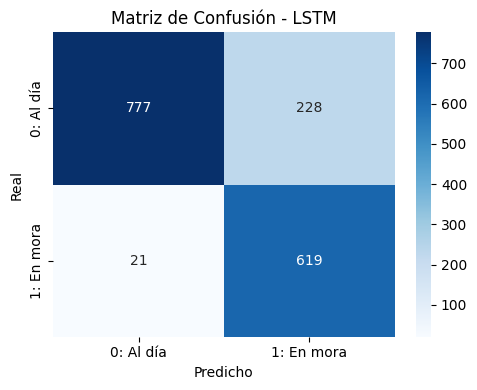

In [28]:
print("Reporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=["0: Al día", "1: En mora"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["0: Al día", "1: En mora"],
            yticklabels=["0: Al día", "1: En mora"])
plt.title("Matriz de Confusión - LSTM")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()



### **Curvas de entrenamiento**

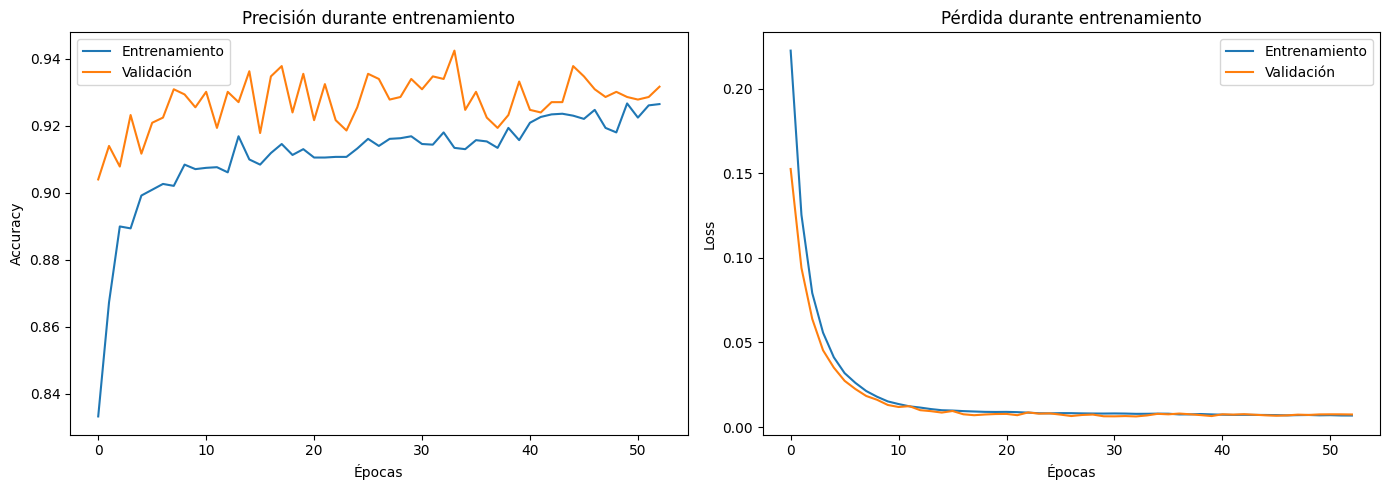

In [27]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión durante entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida durante entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
